# Data cleaning EDA and basic statistical analysis  useing Titanic Dataset 

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
dataset = pd.read_csv('train.csv')
dataset.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


* check missing value

In [4]:
dataset.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
dataset.shape

(891, 12)

* Handle missing value

In [6]:
dataset['Age'].fillna(dataset['Age'].median(), inplace=True)
dataset['Cabin'].fillna('Unknknown',inplace=True)
dataset['Embarked'].fillna(dataset['Embarked'].mode()[0],inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_1632\2211745369.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Age'].fillna(dataset['Age'].median(), inplace=True)
C:\Users\Asus\AppData\Local\Temp\ipykernel_1632\2211745369.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


* here age missing value fill with median, becouse age numarical value, age has must be outlier, median can not influenced.
* cabin has 70% or more data missing so it we use unknowon
* Embarked column is very less missing .so here we can use mode

In [7]:
dataset.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


* handle duplicate

In [9]:
dataset.duplicated().any()

False

* here this dataset has not any duplicate value. if any duplicate value is available then we can..... 

In [10]:
dataset.drop_duplicates(inplace=True)

* This dataset has no date formate columns, but here available the date formate column then we can satanderd formate this way

In [11]:
# dataset['dateFormate'] = pd.to_datetime(dataset['dateFrmate'])
# dataset

* create age groups

In [12]:
def age_group(Age):
    if Age < 18:
        return 'Child'
    elif Age < 60:
        return 'Adult'
    else:
        return 'senior'

In [13]:
dataset["Age_group"] = dataset['Age'].apply(age_group)
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknknown,S,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknknown,S,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknknown,S,Adult


* outlier detect

EDA

In [14]:
dataset.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: xlabel='Age'>

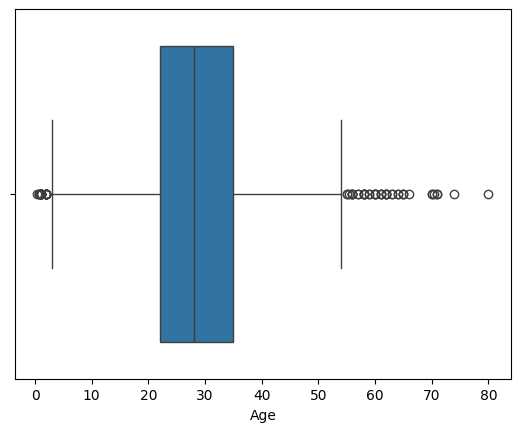

In [15]:
sns.boxplot(x='Age',data = dataset)

<Axes: xlabel='Fare'>

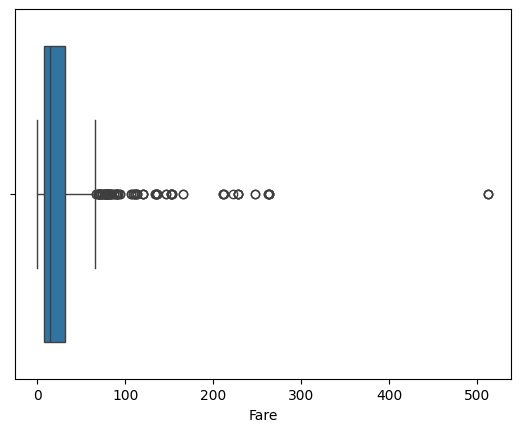

In [16]:
sns.boxplot(x='Fare',data = dataset)

here outlier present

* handle outlier

In [17]:
dataset["Age"].skew(), dataset["Fare"].skew()

(0.5102446555756495, 4.787316519674893)

* age > 0 = right skew
* fare > 0 = right skew

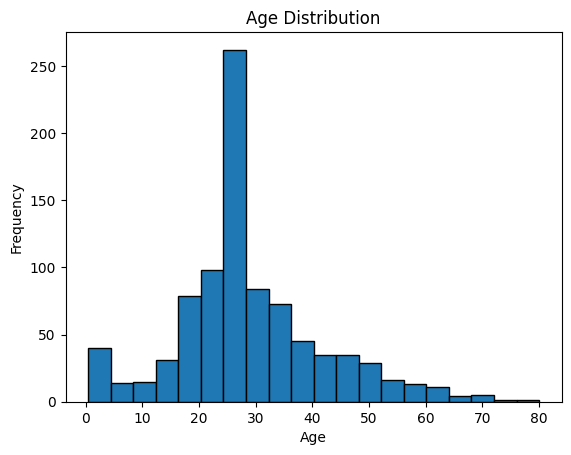

In [18]:
plt.hist(dataset['Age'].dropna(), bins=20, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

right skew

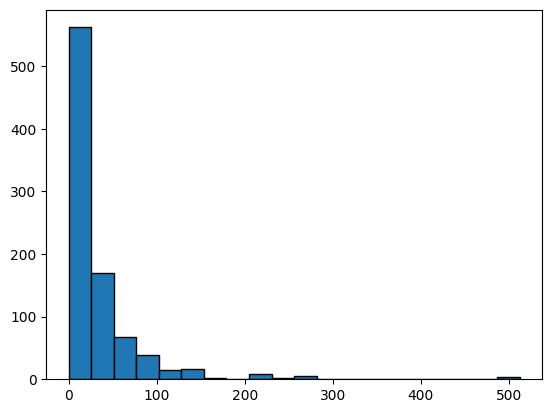

In [19]:
plt.hist(dataset['Fare'].dropna(),bins=20,edgecolor='black')
plt.show()

right skew

* we know if data is skewed then we can use IQR method or z-score  

In [20]:
columns = ['Age', 'Fare']
for col in columns:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 = Q1
    lower = Q1 - 1.5 * IQR
    upper = Q1 + 1.5 * IQR
    dataset[col] = np.clip(dataset[col],lower,upper)


In [21]:
dataset["Age"].skew(), dataset["Fare"].skew()

(0.1488225035015203, -0.25607967641703544)

<Axes: xlabel='Age'>

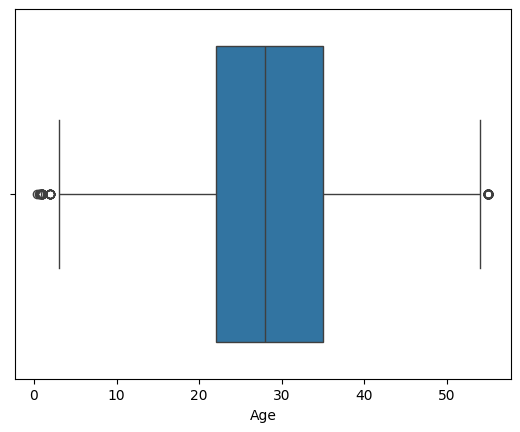

In [22]:
sns.boxplot(x='Age',data = dataset)

<Axes: xlabel='Fare'>

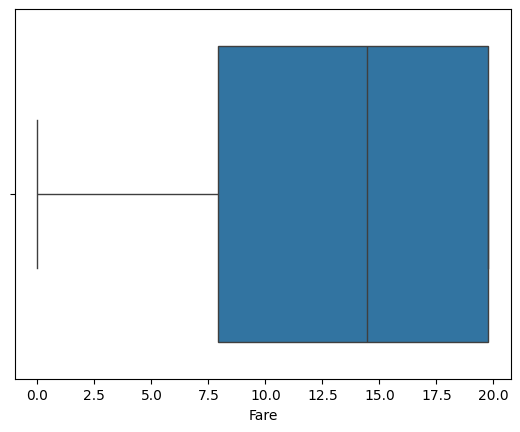

In [23]:
sns.boxplot(x='Fare',data = dataset)

now no outlier in the fare column

* now we can try z score method

In [24]:
from scipy import stats

columns = ['Age', 'Fare']
z_scores = np.abs(stats.zscore(dataset[columns]))
z_scores.head()

,Age,Fare
0,0.577048,1.182306
1,0.735989,1.022384
2,0.248789,1.063500
3,0.489794,1.022384
4,0.489794,1.041499


In [25]:
df_z = dataset[(z_scores < 3).all(axis = 1)]

In [26]:
df_z["Age"].skew(), df_z["Fare"].skew()

(0.1488225035015203, -0.25607967641703544)

* gender split using bar plot 

* Gender count

In [27]:
gender_counts = dataset['Sex'].value_counts()
gender_counts

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='Sex', ylabel='count'>

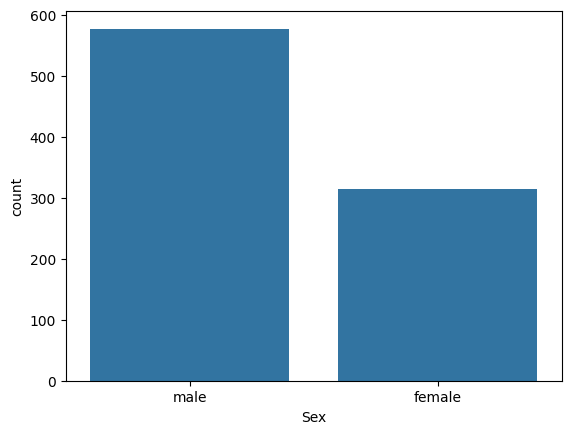

In [28]:
sns.countplot(x='Sex',data=dataset)

<Axes: xlabel='Age', ylabel='Count'>

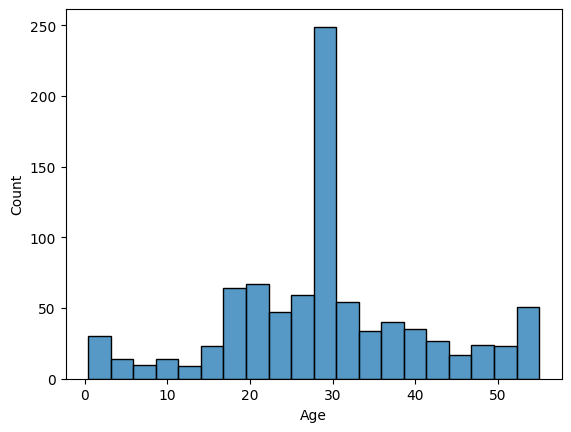

In [29]:
sns.histplot(dataset["Age"],bins=20,)

* survival rate

<Axes: xlabel='Survived', ylabel='count'>

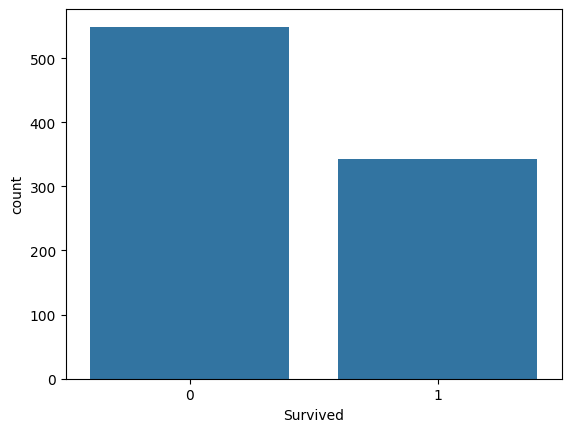

In [30]:
sns.countplot(x='Survived',data=dataset)

* According to gender class survival rate

C:\Users\Asus\AppData\Local\Temp\ipykernel_1632\1376896834.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex',y='Survived',data=dataset,palette='pastel')


Text(0.5, 1.0, 'Survial rate by gender')

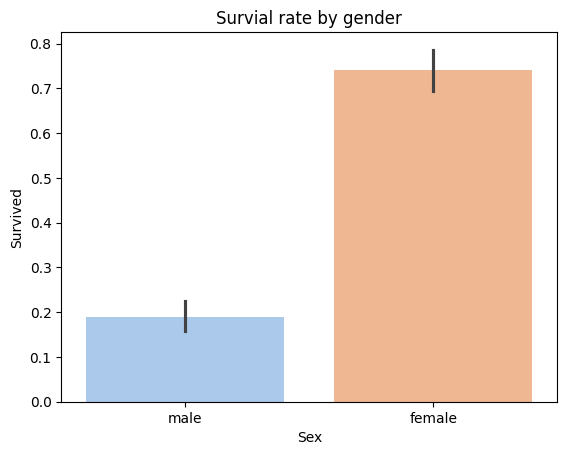

In [31]:
sns.barplot(x='Sex',y='Survived',data=dataset,palette='pastel')
plt.title('Survial rate by gender')

* According to passenger class survival rate 

C:\Users\Asus\AppData\Local\Temp\ipykernel_1632\3399681732.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass',y='Survived',data=dataset,palette ='pastel')


<Axes: xlabel='Pclass', ylabel='Survived'>

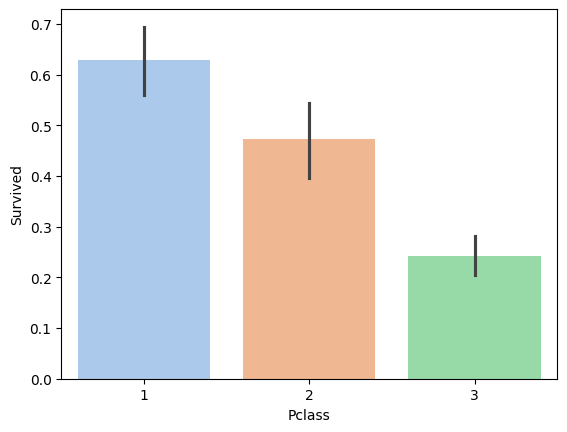

In [32]:
sns.barplot(x='Pclass',y='Survived',data=dataset,palette ='pastel')

In [33]:
columns = ['Age','Fare']
for col in columns:
    mean = dataset[col].mean()
    median = dataset[col].median()
    mode = dataset[col].mode()[0]

    print(f"{col}:")
    print(f"  Mean   = {mean:.2f}")
    print(f"  Median = {median:.2f}")
    print(f"  Mode   = {mode}\n")

Age:
  Mean   = 29.03
  Median = 28.00
  Mode   = 28.0

Fare:
  Mean   = 13.97
  Median = 14.45
  Mode   = 19.776



* T-test

In [34]:
male_survived = dataset[dataset['Sex'] == 'male']['Survived']
female_survived = dataset[dataset['Sex'] == 'female']['Survived']

In [36]:
t_stat, p_value = stats.ttest_ind(male_survived,female_survived)
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

T-statistic: -19.298
P-value: 0.000


In [37]:
if p_value < 0.05:
    print("Result: Significant difference in survival rate between genders.")
else:
    print("Result: No significant difference in survival rate between genders.")

Result: Significant difference in survival rate between genders.


* here man and female survival rate is not same 